In [1]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import ee, geemap
from shapely.geometry import mapping
import rasterio as rio
import matplotlib.pyplot as plt
from rasterio.plot import show
from rasterstats import zonal_stats
from rasterio.plot import plotting_extent 

In [2]:
os.chdir('..')
os.getcwd()

'/Users/rujalshrestha/Projects/mac-migration/gisc-412/nepal-wildfire'

In [3]:
ee.Authenticate()
ee.Initialize(project='gis-412')
ee.Initialize()

In [4]:
bardiya_mun = gpd.read_file('output/bardiya_municipalities.gpkg')

In [5]:
bardiya_union = bardiya_mun.geometry.union_all()

# Obtaining Data from Google Earth Engine

In [6]:
bardiya_union_ee = ee.Geometry(mapping(bardiya_union))

# unlike elevation and boundaries, trying google earth engine to get climate and vegetation data for Nepal like in lab

# Vegetation
ndvi = ee.ImageCollection("MODIS/061/MOD13Q1").select("NDVI") \
           .filterDate("2000-01-01", "2025-09-30").mean().clip(bardiya_union_ee)

# land surface temperature (LST)
lst = ee.ImageCollection("MODIS/061/MOD11A2").select("LST_Day_1km") \
          .filterDate("2000-01-01", "2025-09-30").mean().clip(bardiya_union_ee).multiply(0.02) # original data is scaled

# Precipitation
precip = ee.Image("WORLDCLIM/V1/BIO").select("bio12").clip(bardiya_union_ee)

# Temperature
temp = ee.Image("WORLDCLIM/V1/BIO").select("bio01").clip(bardiya_union_ee)

# uncomment to download. I have already downloaded these, so commented to avoid redownloading
# geemap.ee_export_image(ndvi, "data/Climate/Bardiya_NDVI.tif", scale=250, region=bardiya_union_ee)
# geemap.ee_export_image(lst, "data/Climate/Bardiya_LST.tif", scale=1000, region=bardiya_union_ee)
# geemap.ee_export_image(precip, "data/Climate/Bardiya_Precip.tif", scale=1000, region=bardiya_union_ee)
# geemap.ee_export_image(temp, "data/Climate/Bardiya_Temp.tif", scale=1000, region=bardiya_union_ee)

In [7]:
def show_stats(df, unit):
  # Print summary stats
  print(f"Mean: {np.mean(df):.2f} {unit}")
  print(f"Min: {np.min(df):.2f} {unit}")
  print(f"Max: {np.max(df):.2f} {unit}")
  print(f"Std Dev: {np.std(df):.2f} {unit}")

In [8]:
files = [
    ("NDVI", "NDVI (Vegetation)"),
    ("LST", "Land Surface Temperature (K)"),
    ("Precip", "Annual Precipitation (mm)"),
    ("Temp", "Mean Temperature (K)"),
]

stats = []

for path, title in files:
    with rio.open(f'data/Climate/Bardiya_{path}.tif') as src:
        data = src.read(1).astype(float)
        
        
        # filter out no-data
        nodata = src.nodata
                
        if nodata is not None:
            data[data == nodata] = np.nan
        
        data = data[np.isfinite(data)]
                
        if len(data) == 0:
            continue

        stats.append({
            "Variable": title,
            "Mean": np.mean(data),
            "Min": np.min(data),
            "Max": np.max(data),
            "Standard Dev": np.std(data)
        })

df = pd.DataFrame(stats)
print(df.round(3))

                       Variable      Mean       Min       Max  Standard Dev
0             NDVI (Vegetation)  5719.682   122.060  7738.621      1200.716
1  Land Surface Temperature (K)   300.423   294.657   303.952         1.757
2     Annual Precipitation (mm)  1600.395  1091.000  2001.000       229.887
3          Mean Temperature (K)   234.975   139.000   248.000        17.746


# LST

In [9]:
with rio.open("data/Climate/Bardiya_LST.tif") as src:
    lst = src.read(1).astype(float)
    lst_celsius = lst - 273.15 # Convert from Kelvin to Celsius
    lst_celsius[lst_celsius <= 0] = np.nan
    transform = src.transform
    crs = src.crs

lst_flat = lst_celsius[np.isfinite(lst_celsius)]
show_stats(lst_flat, '°C')

Mean: 27.27 °C
Min: 21.51 °C
Max: 30.80 °C
Std Dev: 1.76 °C


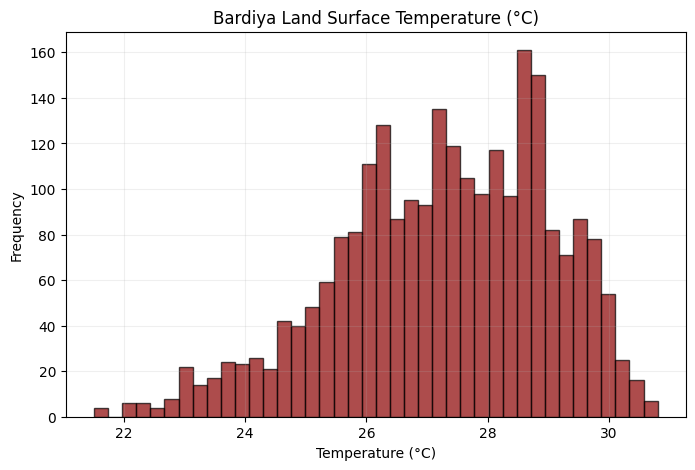

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(lst_flat, bins=40, color="darkred", edgecolor="black", alpha=0.7)
plt.title("Bardiya Land Surface Temperature (°C)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.grid(alpha=0.2)
plt.show()

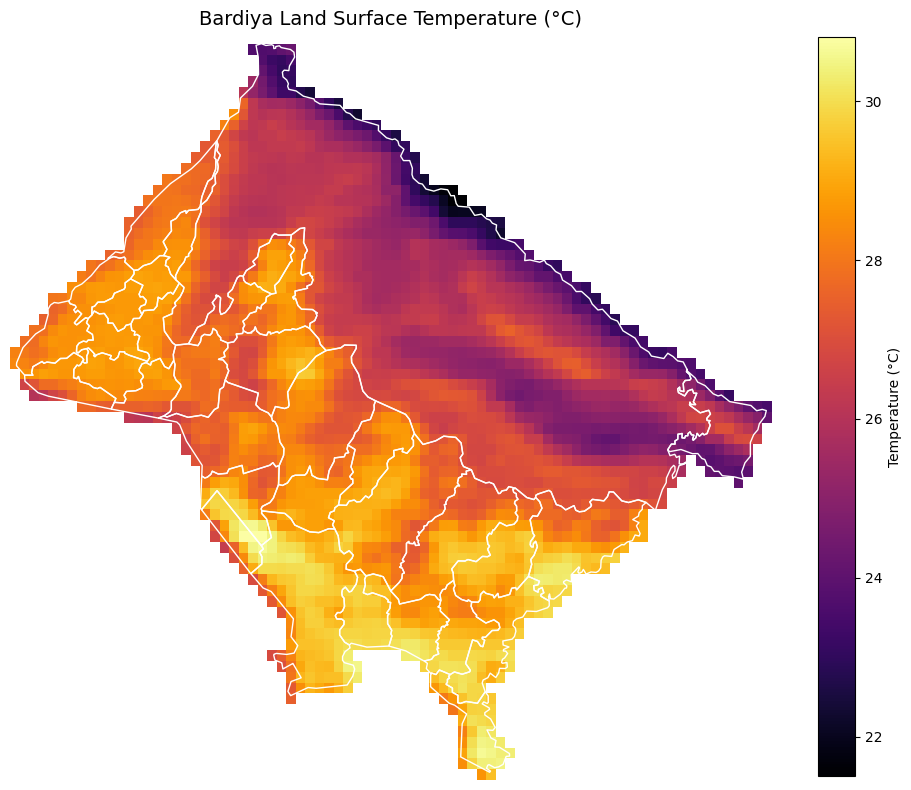

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
show(lst_celsius, transform=transform, cmap="inferno", ax=ax)
bardiya_mun.boundary.plot(ax=ax, color="white", linewidth=1)

ax.set_title("Bardiya Land Surface Temperature (°C)", fontsize=14)
ax.set_axis_off()
plt.colorbar(ax.images[0], ax=ax, label="Temperature (°C)", fraction=0.04)
plt.tight_layout()
plt.show()

# NDVI

Mean: 0.57 
Min: 0.01 
Max: 0.77 
Std Dev: 0.12 


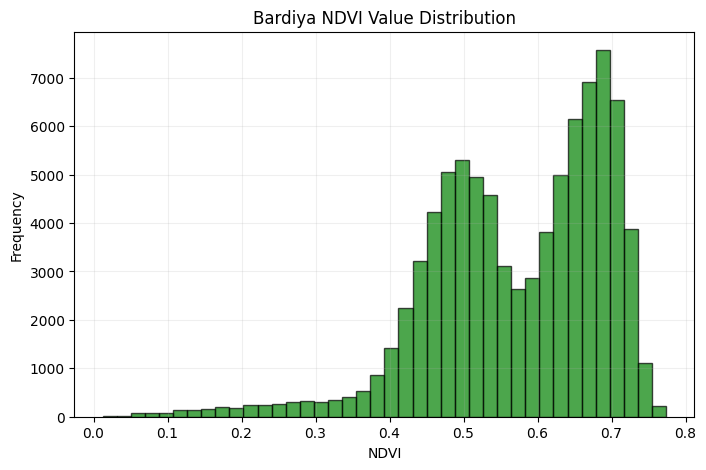

In [12]:
with rio.open("data/Climate/Bardiya_NDVI.tif") as src:
    ndvi = src.read(1).astype(float)
    ndvi[ndvi <= 0] = np.nan  
    ndvi = ndvi / 10000 # convert to 0-1 scale
    transform = src.transform
    crs = src.crs

show_stats(ndvi, '')

plt.figure(figsize=(8, 5))
plt.hist(ndvi[np.isfinite(ndvi)], bins=40, color="green", edgecolor="black", alpha=0.7)
plt.title("Bardiya NDVI Value Distribution")
plt.xlabel("NDVI")
plt.ylabel("Frequency")
plt.grid(alpha=0.2)
plt.show()

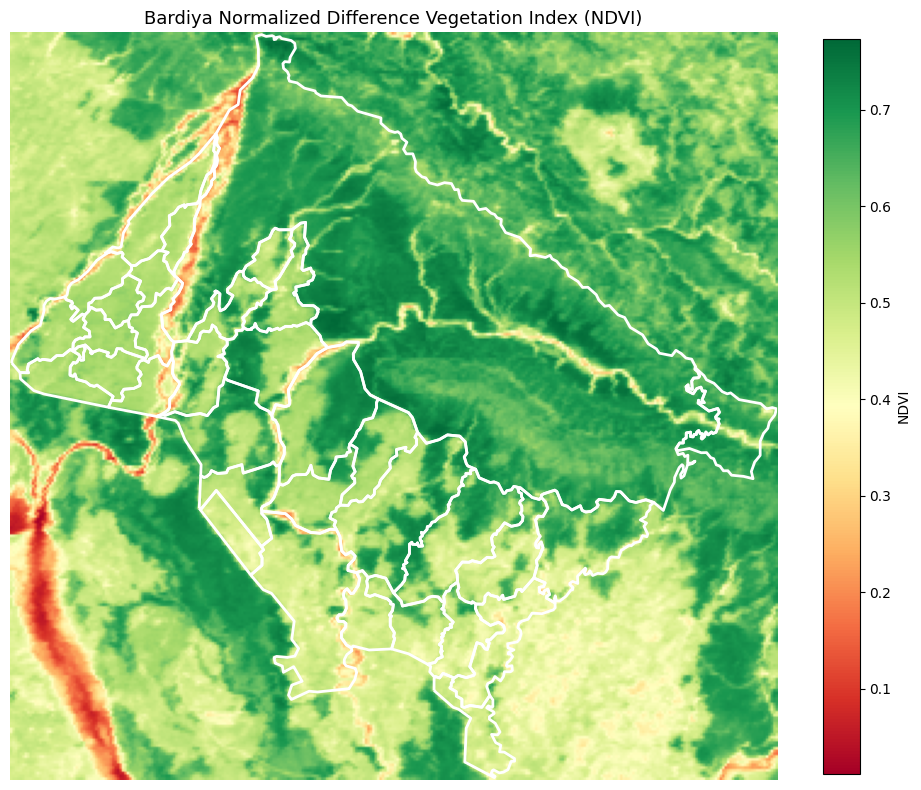

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))
show(ndvi, transform=transform, cmap="RdYlGn", ax=ax)
bardiya_mun.boundary.plot(ax=ax, color="white", linewidth=2)
ax.set_title("Bardiya Normalized Difference Vegetation Index (NDVI)", fontsize=13)
ax.set_axis_off()
plt.colorbar(ax.images[0], ax=ax, label="NDVI", fraction=0.04)
plt.tight_layout()
plt.show()

# Annual Precipitation

In [22]:
with rio.open("data/Climate/Bardiya_Precip.tif") as src:
    precip = src.read(1).astype(float)
    precip[precip <= 0] = np.nan 
    transform = src.transform
    crs = src.crs

show_stats(precip, 'mm')

Mean: 1600.40 mm
Min: 1091.00 mm
Max: 2001.00 mm
Std Dev: 229.89 mm


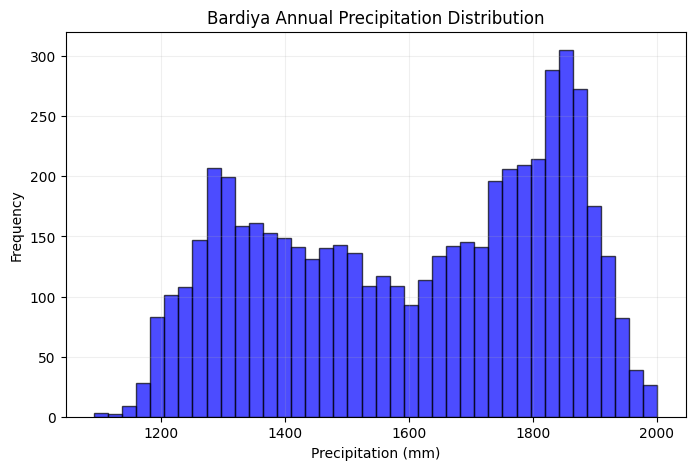

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(precip[np.isfinite(precip)], bins=40, color="blue", edgecolor="black", alpha=0.7)
plt.title("Bardiya Annual Precipitation Distribution")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")
plt.grid(alpha=0.2)
plt.show()

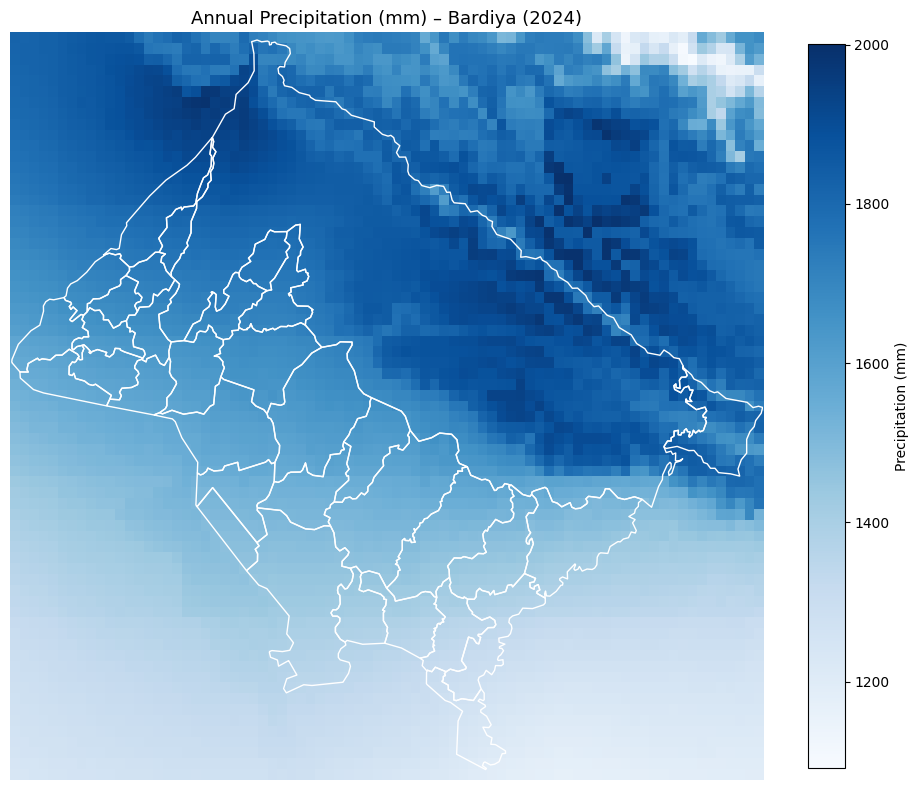

In [24]:
fig, ax = plt.subplots(figsize=(10, 8))
show(precip, transform=transform, cmap="Blues", ax=ax)
bardiya_mun.boundary.plot(ax=ax, color="white", linewidth=1)
ax.set_axis_off()
ax.set_title("Annual Precipitation (mm) – Bardiya (2024)", fontsize=13)
plt.colorbar(ax.images[0], ax=ax, label="Precipitation (mm)", fraction=0.04)
plt.tight_layout()
plt.show()

# Mean Temperature

In [26]:
with rio.open("data/Climate/Bardiya_Temp.tif") as src:
    temp = src.read(1).astype(float)
    temp[temp <= 0] = np.nan  
    temp = (temp / 10) # scale by 0.1 (°C)
    transform = src.transform
    crs = src.crs

show_stats(temp, '°C')

Mean: 23.50 °C
Min: 13.90 °C
Max: 24.80 °C
Std Dev: 1.77 °C


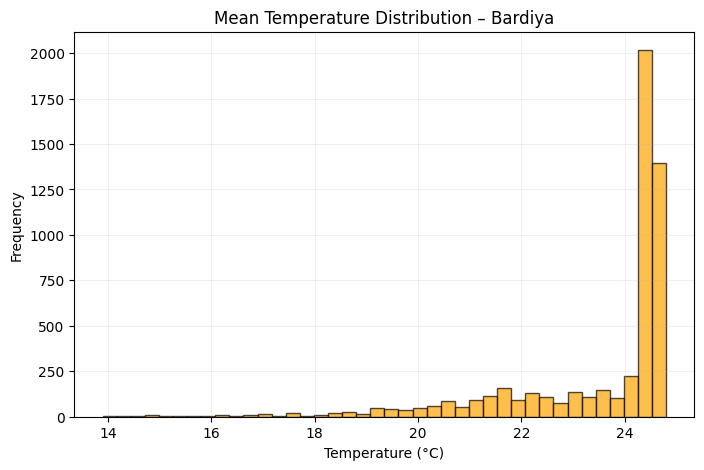

In [27]:
plt.figure(figsize=(8, 5))
plt.hist(temp[np.isfinite(temp)], bins=40, color="orange", edgecolor="black", alpha=0.7)
plt.title("Mean Temperature Distribution – Bardiya")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.grid(alpha=0.2)
plt.show()

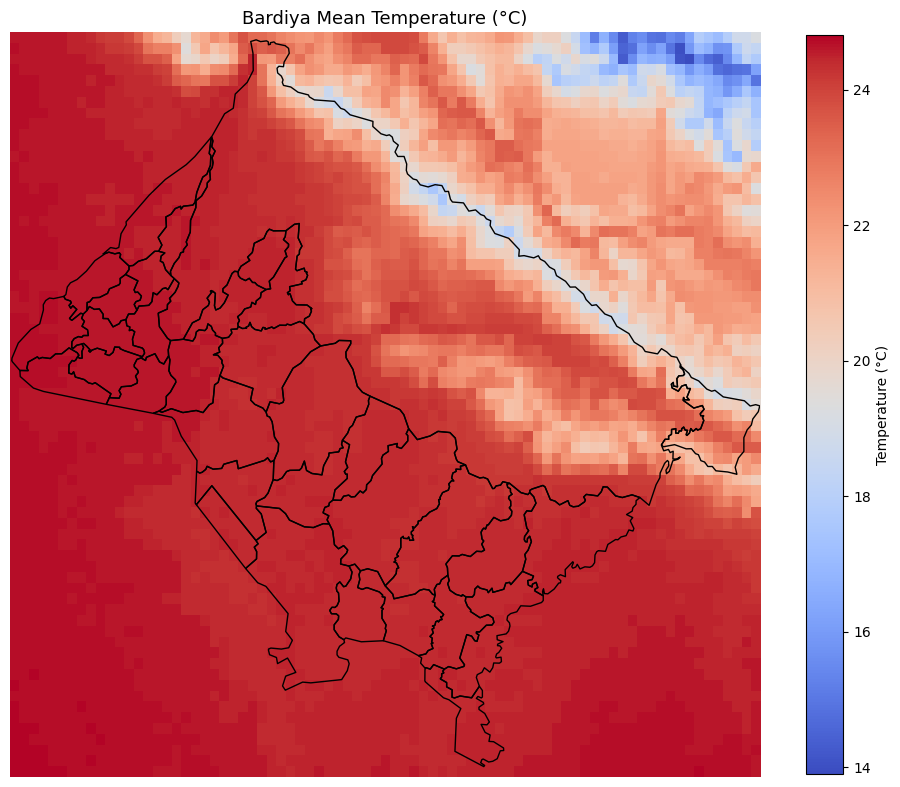

In [28]:
fig, ax = plt.subplots(figsize=(10, 8))
show(temp, transform=transform, cmap="coolwarm", ax=ax)
bardiya_mun.boundary.plot(ax=ax, color="black", linewidth=1)
ax.set_title("Bardiya Mean Temperature (°C)", fontsize=13)
ax.set_axis_off()
plt.colorbar(ax.images[0], ax=ax, label="Temperature (°C)", fraction=0.04)
plt.tight_layout()
plt.show()